<a href="https://colab.research.google.com/github/rinviriti/AI-ML-Learning-Journey/blob/main/10_computer_vision/cat_vs_dog_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Cat vs Dog Classification using Convolutional Neural Networks (CNN)

Image classification is one of the most common tasks in Computer Vision.

The goal is to train a model that can recognize the contents of an image.

In this project, we will build a Convolutional Neural Network (CNN) that can classify images as either:

- Cat
- Dog

This is called **Binary Classification** because there are only two possible classes.

## Learning Objectives

After completing this notebook, you will be able to:

- Understand image classification
- Load image datasets using TensorFlow
- Prepare image data for deep learning
- Build a CNN model
- Train and evaluate the model
- Make predictions on unseen images

# Step 1: Import Required Libraries

Before building a deep learning model, we need several libraries:

### TensorFlow
Used for building and training neural networks.

### NumPy
Used for numerical operations and array manipulation.

### Matplotlib
Used for visualizing images and training results.

In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.20.0


# Step 2: Load the Dataset

We will use the CIFAR-10 dataset.

CIFAR-10 contains 60,000 color images belonging to 10 different categories:

1. Airplane
2. Automobile
3. Bird
4. Cat
5. Deer
6. Dog
7. Frog
8. Horse
9. Ship
10. Truck

Since our goal is Cat vs Dog classification, we will keep only:

- Cat (Class 3)
- Dog (Class 5)

and remove all other classes.

In [2]:
from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2327s 14us/step
Training Shape: (50000, 32, 32, 3)
Testing Shape: (10000, 32, 32, 3)


# Step 3: Filter Only Cats and Dogs

The original dataset contains 10 classes.

We only need:

- Cat
- Dog

Therefore, we create masks to select those images and discard the rest.

In [3]:
CAT_CLASS = 3
DOG_CLASS = 5

train_mask = np.logical_or(
    y_train.flatten() == CAT_CLASS,
    y_train.flatten() == DOG_CLASS
)

test_mask = np.logical_or(
    y_test.flatten() == CAT_CLASS,
    y_test.flatten() == DOG_CLASS
)

X_train = X_train[train_mask]
y_train = y_train[train_mask]

X_test = X_test[test_mask]
y_test = y_test[test_mask]

print("Filtered Training Images:", X_train.shape)
print("Filtered Testing Images:", X_test.shape)

Filtered Training Images: (10000, 32, 32, 3)
Filtered Testing Images: (2000, 32, 32, 3)


# Step 4: Convert Labels

Currently:

- Cat = 3
- Dog = 5

For binary classification, it is easier to use:

- Cat = 0
- Dog = 1

This simplifies model training and prediction.

In [4]:
y_train = (y_train == DOG_CLASS).astype(int)
y_test = (y_test == DOG_CLASS).astype(int)

print(np.unique(y_train))

[0 1]


# Step 5: Visualize Sample Images

Before training a model, it is important to inspect the dataset.

This helps us:

- Verify that the images loaded correctly
- Understand the classification task
- Identify potential data quality issues

/tmp/ipykernel_3415/4189144925.py:12: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(y_train[i])


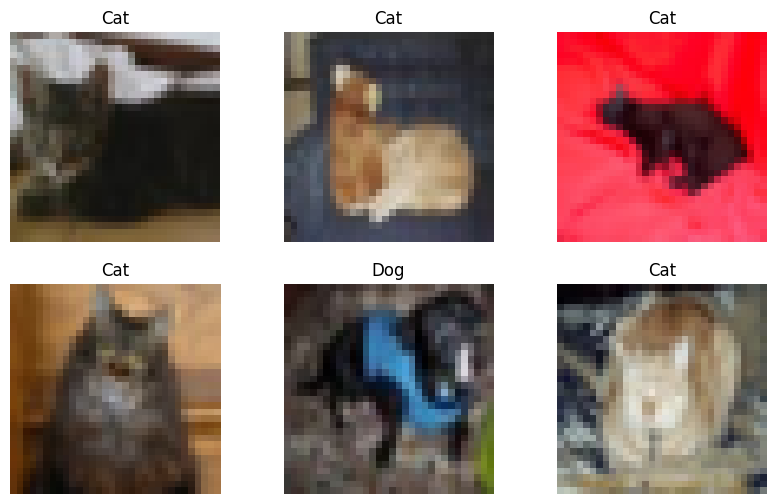

In [5]:
class_names = ["Cat", "Dog"]

plt.figure(figsize=(10,6))

for i in range(6):
    plt.subplot(2,3,i+1)

    plt.imshow(X_train[i])

    plt.title(
        class_names[
            int(y_train[i])
        ]
    )

    plt.axis("off")

plt.show()

# Step 6: Normalize Image Pixels

Image pixel values range from:

0 → 255

Neural networks learn better when inputs are scaled to a smaller range.

We divide every pixel by 255 so that values fall between:

0 → 1

This process is called **Normalization**.

In [6]:
X_train = X_train / 255.0
X_test = X_test / 255.0

print(X_train.shape)
print(X_test.shape)

# Step 7: Build a CNN Model

Convolutional Neural Networks are specifically designed for image data.

A CNN learns image features in stages:

### Convolution Layer
Detects edges and patterns.

### Pooling Layer
Reduces image size and computational cost.

### Dense Layer
Combines extracted features for classification.

### Output Layer
Produces the final prediction.

In [7]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D,
    MaxPooling2D,
    Flatten,
    Dense,
    Dropout
)

model = Sequential([

    Conv2D(
        32,
        (3,3),
        activation="relu",
        input_shape=(32,32,3)
    ),

    MaxPooling2D((2,2)),

    Conv2D(
        64,
        (3,3),
        activation="relu"
    ),

    MaxPooling2D((2,2)),

    Flatten(),

    Dense(
        128,
        activation="relu"
    ),

    Dropout(0.5),

    Dense(
        1,
        activation="sigmoid"
    )

])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 314,561 (1.20 MB)

 Trainable params: 314,561 (1.20 MB)

 Non-trainable params: 0 (0.00 B)

# Step 8: Compile the Model

Before training, we must configure:

### Optimizer

Adam optimizer adjusts model weights efficiently.

### Loss Function

Binary Crossentropy is suitable for binary classification tasks.

### Evaluation Metric

Accuracy measures how many predictions are correct.

In [8]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

# Step 9: Train the Model

Training means showing images to the network and allowing it to learn patterns.

Each epoch represents one complete pass through the training dataset.

As training progresses, we expect:

- Training accuracy to increase
- Loss to decrease

In [9]:
history = model.fit(
    X_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

Epoch 1/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 15s 51ms/step - accuracy: 0.5683 - loss: 0.6746 - val_accuracy: 0.6460 - val_loss: 0.6417
Epoch 2/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 12s 50ms/step - accuracy: 0.6606 - loss: 0.6198 - val_accuracy: 0.6780 - val_loss: 0.5980
Epoch 3/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 18s 42ms/step - accuracy: 0.7009 - loss: 0.5729 - val_accuracy: 0.7070 - val_loss: 0.5715
Epoch 4/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 11s 45ms/step - accuracy: 0.7191 - loss: 0.5466 - val_accuracy: 0.6765 - val_loss: 0.5870
Epoch 5/5
250/250 ━━━━━━━━━━━━━━━━━━━━ 21s 48ms/step - accuracy: 0.7431 - loss: 0.5169 - val_accuracy: 0.7090 - val_loss: 0.5575


# Step 10: Evaluate the Model

After training, we test the model on images it has never seen before.

This helps measure how well the model generalizes to new data.

In [10]:
test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test
)

print("Test Accuracy:", test_accuracy)

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7105 - loss: 0.5480
Test Accuracy: 0.7105000019073486


# Step 11: Visualize Learning Progress

Training and validation accuracy help us determine:

- Whether the model is learning
- Whether overfitting is occurring
- Whether additional training is needed

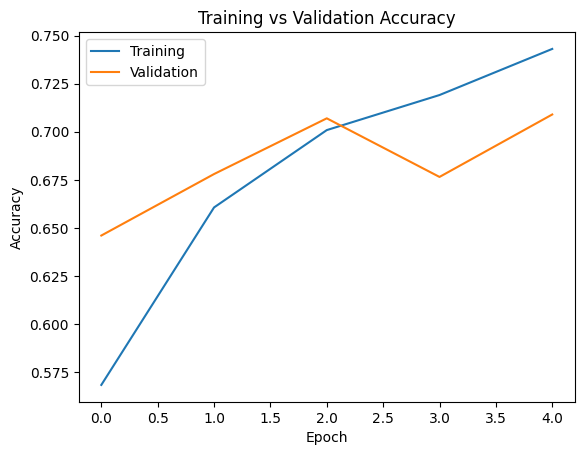

In [11]:
plt.plot(
    history.history["accuracy"],
    label="Training"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation"
)

plt.title("Training vs Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.show()

# Step 12: Make Predictions

The trained model outputs a probability.

If the probability is:

- Less than 0.5 → Cat
- Greater than 0.5 → Dog

Let's test the model on unseen images.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step


/tmp/ipykernel_3415/3800416625.py:14: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  int(y_test[i])


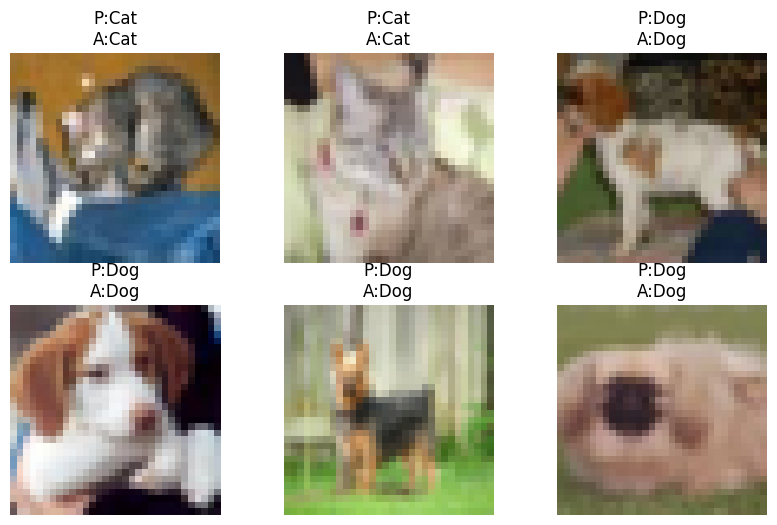

In [12]:
predictions = model.predict(X_test[:6])

plt.figure(figsize=(10,6))

for i in range(6):

    plt.subplot(2,3,i+1)

    plt.imshow(X_test[i])

    predicted = "Dog" if predictions[i] > 0.5 else "Cat"

    actual = class_names[
        int(y_test[i])
    ]

    plt.title(
        f"P:{predicted}\nA:{actual}"
    )

    plt.axis("off")

plt.show()

# Conclusion

In this project, we built a CNN model for Cat vs Dog image classification.

## What I Learned

- Binary Image Classification
- Dataset Filtering
- Image Normalization
- Convolutional Neural Networks
- Model Training
- Model Evaluation
- Prediction on New Images

This project provides a foundation for more advanced Computer Vision applications such as skin lesion classification, medical imaging analysis, and MobileSkinXAI.